# 🏠 House Price Prediction — End-to-End Data Analysis & Machine Learning

**Author: Noureldin Bassem Mohamed**

## 1. Introduction

### Project Objective

The goal of this project is to perform a **complete end-to-end data analysis and machine learning pipeline** on the Ames Housing dataset. Specifically, we aim to:

1. **Explore and understand** the structure, distribution, and quality of the data
2. **Clean and preprocess** the data to prepare it for analysis and modeling
3. **Conduct Exploratory Data Analysis (EDA)** to uncover patterns, relationships, and key drivers of house prices
4. **Analyze Key Performance Indicators (KPIs)** related to house prices
5. **Build regression models** (Linear, Polynomial, Ridge, Lasso, SVR, Random Forest) to predict house prices
6. **Evaluate the models** using standard metrics (R², MAE, MSE) and interpret the results
7. **Discuss underfitting and overfitting** through training vs testing performance
8. **Derive actionable insights and recommendations** based on the findings

## 2. Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning — regression models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Display settings
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

**Tools & Libraries Used:**
- **pandas** — data loading, cleaning, and manipulation
- **numpy** — numerical operations
- **matplotlib & seaborn** — data visualization
- **scikit-learn** — preprocessing, model building, and evaluation (LinearRegression, Ridge, Lasso, SVR, RandomForestRegressor)
- **warnings** — suppress unimportant warnings for cleaner output

## 3. Loading the Dataset

In [4]:
data = pd.read_csv("/content/AmesHousing.csv")
df = data.copy()

We loaded the dataset and created a **copy** to work on. This way, the original raw data is preserved as a safe reference in case we need to undo any changes.

## 4. Data Exploring

In [5]:
df.shape

(2930, 82)

The dataset contains **2,930 rows** (houses) and **82 columns** (features). This gives us a large, rich dataset to work with.

In [6]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


Displayed the first 5 rows to get a quick preview of the data. We can see a mix of numerical and categorical columns, along with some NaN (missing) values.

In [7]:
df.tail()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000
2929,2930,924151050,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,188000


Displayed the last 5 rows to verify the data is complete and consistent at the end of the file.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

**Key observations from `.info()`:**
- The dataset has **82 columns** and **2,930 rows**.
- Data types include: `int64`, `float64`, and `object` (categorical).
- Several columns contain **missing (null) values** — these will be handled in the Data Cleaning section.

In [9]:
df.nunique()

,0
Order,2930
PID,2930
MS SubClass,16
MS Zoning,7
Lot Frontage,128
...,...
Mo Sold,12
Yr Sold,5
Sale Type,10
Sale Condition,6


Checked the number of **unique values per column**. Columns with very few unique values (like 2–5) are likely categorical even if stored as numbers. Columns with too many unique values may not add predictive value.

In [10]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


**Summary statistics for numerical columns:**
- `SalePrice` ranges from **\$12,789 to \$755,000** — a very wide range indicating price diversity.
- `Gr Liv Area` (living area) ranges from **334 to 5,642 sq ft**.
- The mean `Overall Qual` is around **6.1 out of 10**.
- Some columns show a large standard deviation, indicating high variability.

In [11]:
description_obj = df.describe(include='object')
description_obj

,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
count,2930,2930,198,2930,2930,2930,2930,2930,2930,2930,...,2773,2771,2771,2771,2930,13,572,106,2930,2930
unique,7,2,2,4,4,3,5,3,28,9,...,6,3,5,5,3,4,4,5,10,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,2273,2918,120,1859,2633,2927,2140,2789,443,2522,...,1731,1231,2615,2665,2652,4,330,95,2536,2413


**Summary for categorical columns:**
- **Neighborhood** has 28 unique values — houses are spread across many areas.
- **MS Zoning** is dominated by `RL` (Residential Low Density) with 2,273 occurrences.
- Many columns like `Alley`, `Pool QC`, and `Fence` have very few non-null values, suggesting they are mostly missing.

In [12]:
# Check unique values of each categorical column
for col in df.select_dtypes(include='object').columns:
    print(f"--- {col} ---")
    print(df[col].unique())
    print()

--- MS Zoning ---
['RL' 'RH' 'FV' 'RM' 'C (all)' 'I (all)' 'A (agr)']

--- Street ---
['Pave' 'Grvl']

--- Alley ---
[nan 'Pave' 'Grvl']

--- Lot Shape ---
['IR1' 'Reg' 'IR2' 'IR3']

--- Land Contour ---
['Lvl' 'HLS' 'Bnk' 'Low']

--- Utilities ---
['AllPub' 'NoSewr' 'NoSeWa']

--- Lot Config ---
['Corner' 'Inside' 'CulDSac' 'FR2' 'FR3']

--- Land Slope ---
['Gtl' 'Mod' 'Sev']

--- Neighborhood ---
['NAmes' 'Gilbert' 'StoneBr' 'NWAmes' 'Somerst' 'BrDale' 'NPkVill'
 'NridgHt' 'Blmngtn' 'NoRidge' 'SawyerW' 'Sawyer' 'Greens' 'BrkSide'
 'OldTown' 'IDOTRR' 'ClearCr' 'SWISU' 'Edwards' 'CollgCr' 'Crawfor'
 'Blueste' 'Mitchel' 'Timber' 'MeadowV' 'Veenker' 'GrnHill' 'Landmrk']

--- Condition 1 ---
['Norm' 'Feedr' 'PosN' 'RRNe' 'RRAe' 'Artery' 'PosA' 'RRAn' 'RRNn']

--- Condition 2 ---
['Norm' 'Feedr' 'PosA' 'PosN' 'Artery' 'RRNn' 'RRAe' 'RRAn']

--- Bldg Type ---
['1Fam' 'TwnhsE' 'Twnhs' 'Duplex' '2fmCon']

--- House Style ---
['1Story' '2Story' '1.5Fin' 'SFoyer' 'SLvl' '2.5Unf' '1.5Unf' '2.5Fi

Checked all unique values of categorical columns to detect any invalid, inconsistent, or unexpected entries. This helps identify potential data quality issues before cleaning.

In [13]:
# Check missing values
nan_counts = df.isna().sum()
print("Columns with missing values:")
print(nan_counts[nan_counts > 0])

Columns with missing values:
Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64


**Missing value summary:**
- **Alley** (2,732), **Pool QC** (2,917), **Misc Feature** (2,824), and **Fence** (2,358) have extreme amounts of missing data — meaning most houses don't have these features.
- **Lot Frontage** (490) and **Fireplace Qu** (1,422) also have significant missing values.
- These will be addressed in the Data Cleaning section.

## 5. Data Cleaning

### 5.1 Checking for Duplicates

In [14]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


✅ **No duplicate rows** were found. The dataset is clean in terms of duplicate entries.

### 5.2 Dropping High-Missing Columns

In [15]:

threshold = 0.40 * len(df)
cols_to_drop = df.columns[df.isna().sum() > threshold]
df = df.drop(columns=cols_to_drop)

print(f"Dropped columns (>40% missing): {list(cols_to_drop)}")
print(f"Remaining shape: {df.shape}")

Dropped columns (>40% missing): ['Alley', 'Mas Vnr Type', 'Fireplace Qu', 'Pool QC', 'Fence', 'Misc Feature']
Remaining shape: (2930, 76)


Dropped columns with more than 200 missing values. These columns (like **Alley**, **Pool QC**, **Fence**, **Misc Feature**, **Fireplace Qu**, **Mas Vnr Type**) are mostly empty and would not provide reliable information to the model.

### 5.3 Filling Missing Numerical Values

In [16]:
# Fill missing numerical values with the median (robust to outliers)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
print("Numerical missing values filled with median.")

Numerical missing values filled with median.


Used the **median** to fill missing numerical values because it is more robust to outliers than the mean. This preserves the central tendency of the data without being skewed by extreme values.

### 5.4 Filling Missing Categorical Values

In [17]:
# Fill missing categorical values with 'None' (meaning the feature doesn't exist)
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna('None')
print("Categorical missing values filled with 'None'.")

Categorical missing values filled with 'None'.


Filled missing categorical values with `'None'` — this makes logical sense because when a categorical feature is missing (e.g., `Garage Type`), it usually means the house simply **doesn't have** that feature.

In [18]:
# Confirm no missing values remain
remaining_nulls = df.isna().sum().sum()
print(f"Total remaining missing values: {remaining_nulls}")

Total remaining missing values: 0


✅ **All missing values have been handled.** The dataset is now complete and ready for analysis and modeling.

## 6. Exploratory Data Analysis (EDA)

### 6.1 SalePrice Distribution

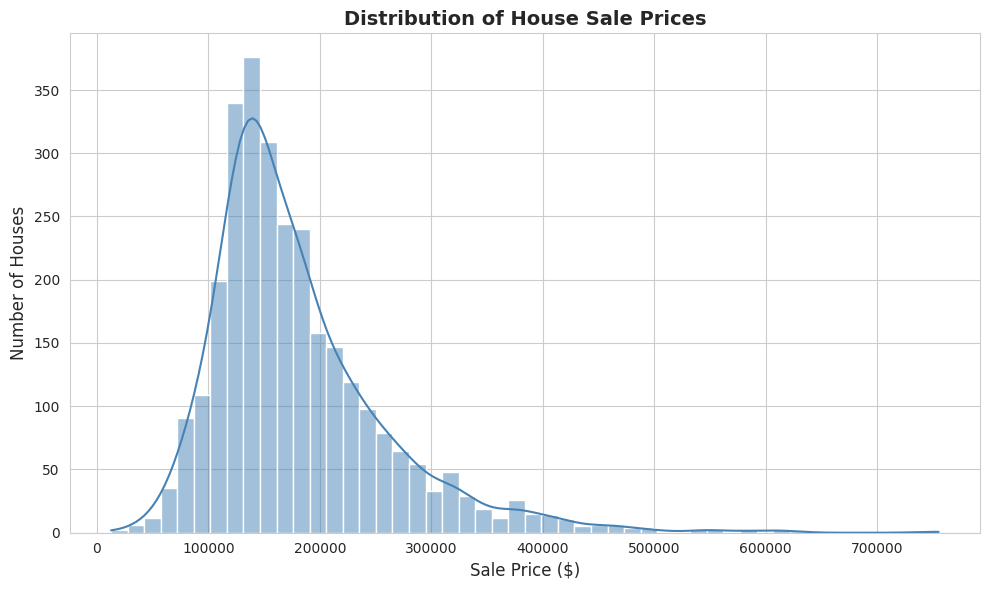

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True, color='steelblue', bins=50)
plt.title('Distribution of House Sale Prices', fontsize=14, fontweight='bold')
plt.xlabel('Sale Price ($)', fontsize=12)
plt.ylabel('Number of Houses', fontsize=12)
plt.tight_layout()
plt.show()

**Key Insight:**
- The distribution is **right-skewed** — most houses are priced between **\$100,000 and \$250,000**.
- A small number of luxury homes push the tail to the right (up to \$755,000).
- This skewness means the **mean price is higher than the median** — the median is a better measure of the "typical" house price.

### 6.2 Correlation Heatmap

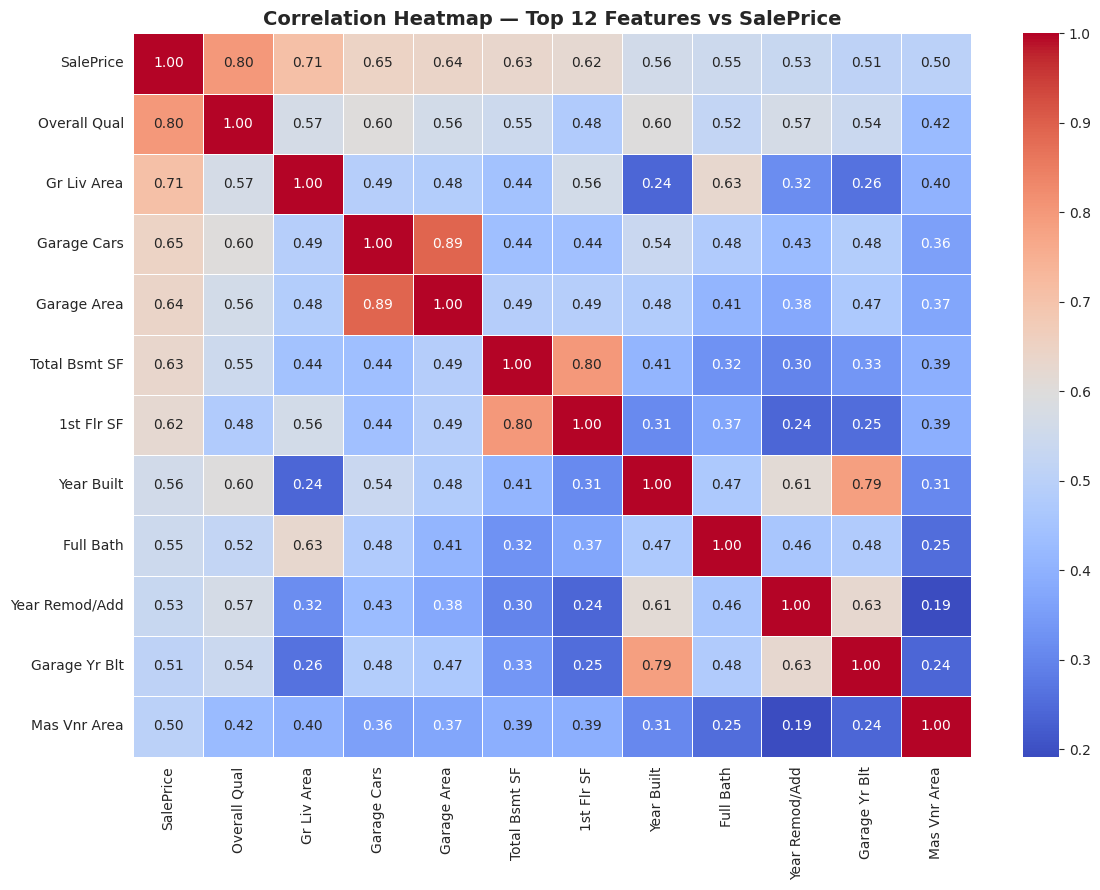

In [20]:
# Calculate correlation with SalePrice for top features
corr_matrix = df.corr(numeric_only=True)

# Select top 12 correlated features for a readable heatmap
top_corr_features = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(12).index
plt.figure(figsize=(12, 9))
sns.heatmap(df[top_corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Top 12 Features vs SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Insight:**
- **Overall Qual** (0.80) and **Gr Liv Area** (0.71) are the strongest predictors of SalePrice.
- **Garage Area**, **Total Bsmt SF**, and **1st Flr SF** also show strong positive correlations.
- Some features are highly correlated with each other (e.g., Garage Area & Garage Cars) — this is called **multicollinearity**, which Ridge/Lasso regression can handle well.

### 6.3 Living Area vs Sale Price

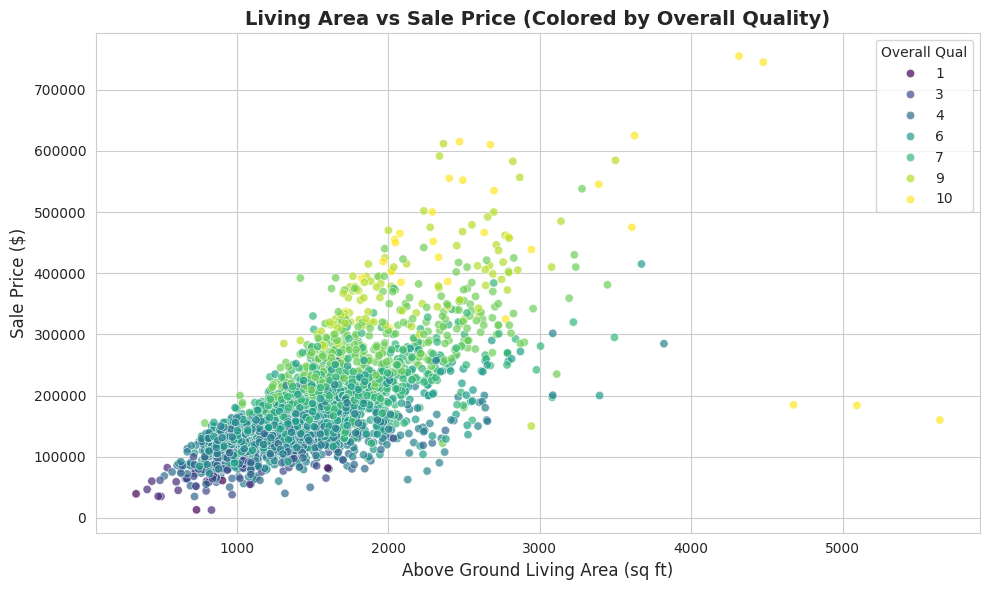

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Gr Liv Area', y='SalePrice', hue='Overall Qual',
                data=df, palette='viridis', alpha=0.7)
plt.title('Living Area vs Sale Price (Colored by Overall Quality)', fontsize=14, fontweight='bold')
plt.xlabel('Above Ground Living Area (sq ft)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.tight_layout()
plt.show()

**Key Insight:**
- There is a **clear positive relationship** between living area and sale price — larger homes sell for more.
- Houses with **higher quality scores** (darker colors) consistently sell for higher prices at the same size.
- Two visible **outliers** exist (very large area but low price) — these may represent unusual sales.

### 6.4 Overall Quality vs Sale Price

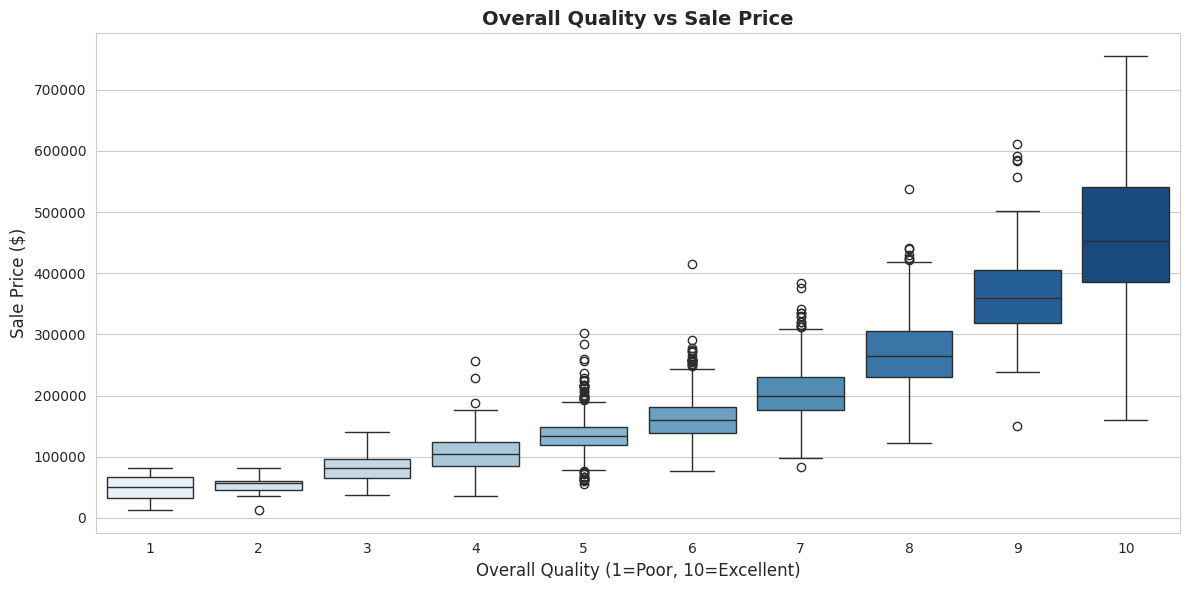

In [22]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Overall Qual', y='SalePrice', data=df, palette='Blues')
plt.title('Overall Quality vs Sale Price', fontsize=14, fontweight='bold')
plt.xlabel('Overall Quality (1=Poor, 10=Excellent)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.tight_layout()
plt.show()

**Key Insight:**
- Sale price **increases sharply** with quality rating.
- Quality 10 homes have a median price roughly **5x higher** than quality 1 homes.
- This confirms that **Overall Quality is the single most important driver** of house prices.

### 6.5 Neighborhood vs Sale Price

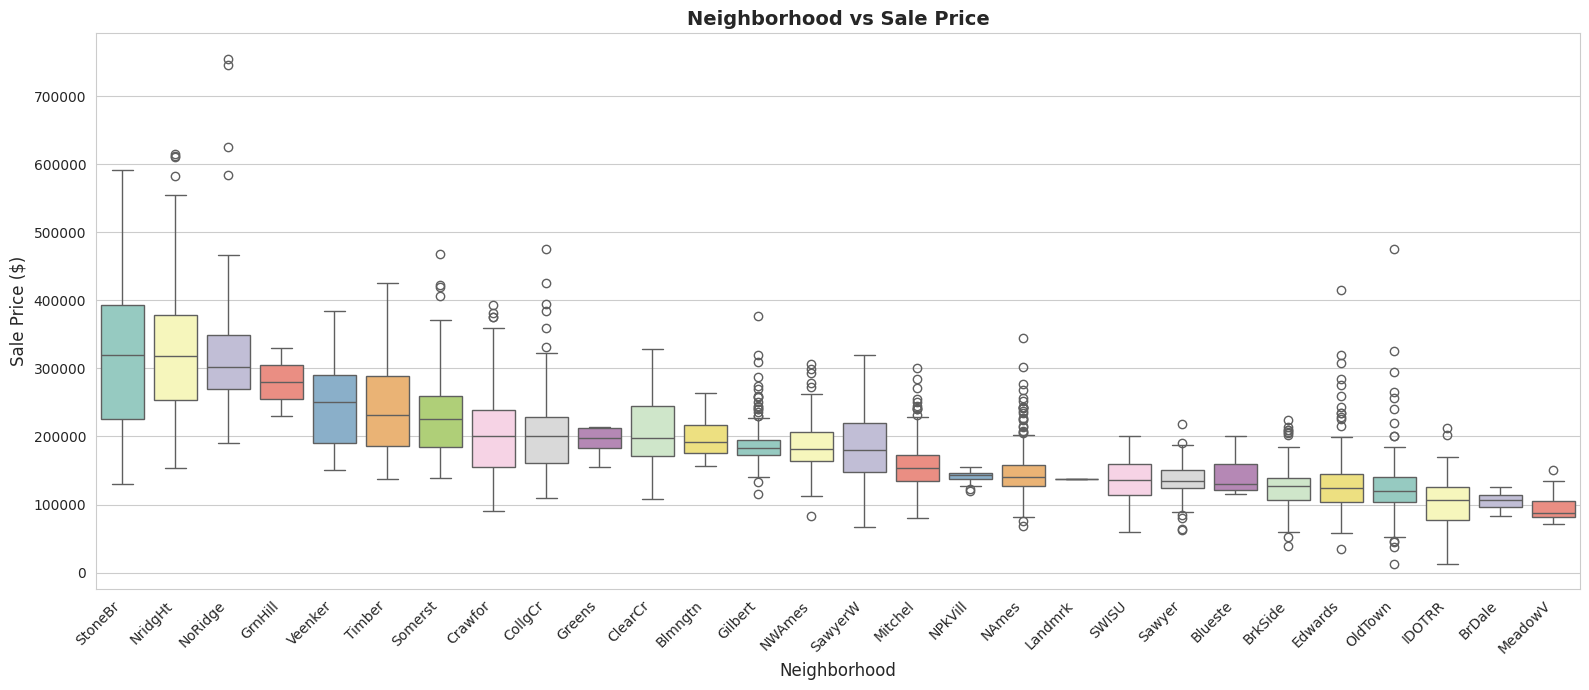

In [23]:
# Calculate median price per neighborhood and sort
neighborhood_order = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index

plt.figure(figsize=(16, 7))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df, order=neighborhood_order, palette='Set3')
plt.title('Neighborhood vs Sale Price', fontsize=14, fontweight='bold')
plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Key Insight:**
- **NoRidge**, **NridgHt**, and **StoneBr** are the most expensive neighborhoods.
- **MeadowV**, **IDOTRR**, and **BrDale** are the most affordable.
- The price spread within neighborhoods varies significantly — some neighborhoods have very inconsistent pricing.

### 6.6 Year Built vs Sale Price

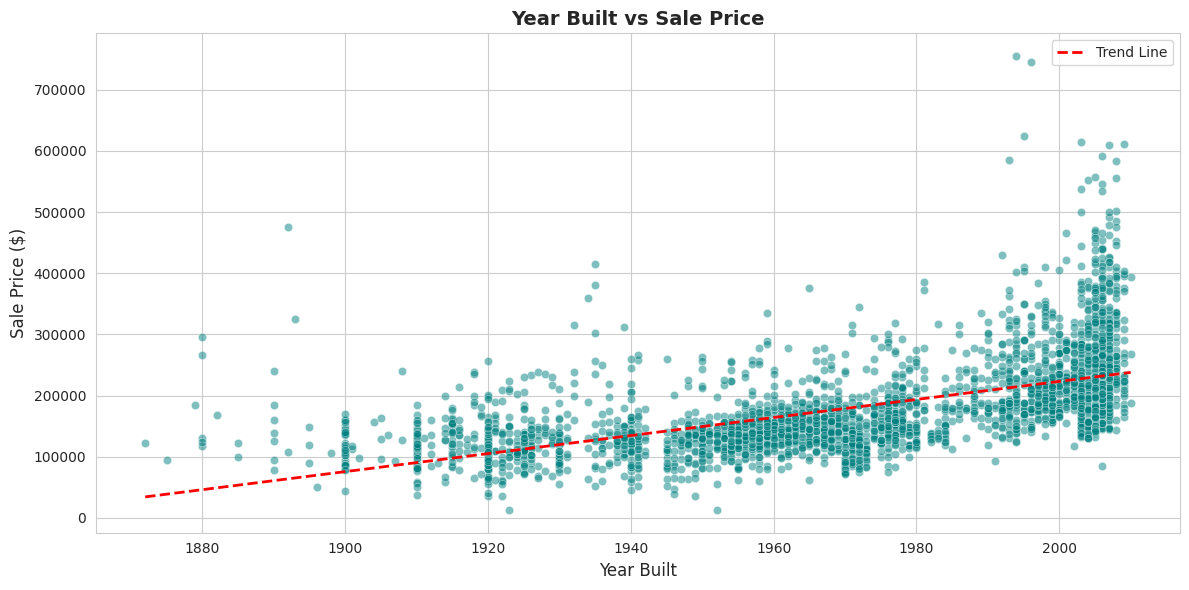

In [24]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Year Built', y='SalePrice', data=df, alpha=0.5, color='teal')
# Add a trend line
z = np.polyfit(df['Year Built'], df['SalePrice'], 1)
p = np.poly1d(z)
plt.plot(sorted(df['Year Built'].unique()), p(sorted(df['Year Built'].unique())),
         'r--', linewidth=2, label='Trend Line')
plt.title('Year Built vs Sale Price', fontsize=14, fontweight='bold')
plt.xlabel('Year Built', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

**Key Insight:**
- **Newer houses tend to sell for higher prices** — there is a clear upward trend after the 1980s.
- Houses built before 1940 show lower and more consistent prices.
- The steep price rise for post-2000 construction reflects modern amenities and design preferences.

### 6.7 Outlier Detection

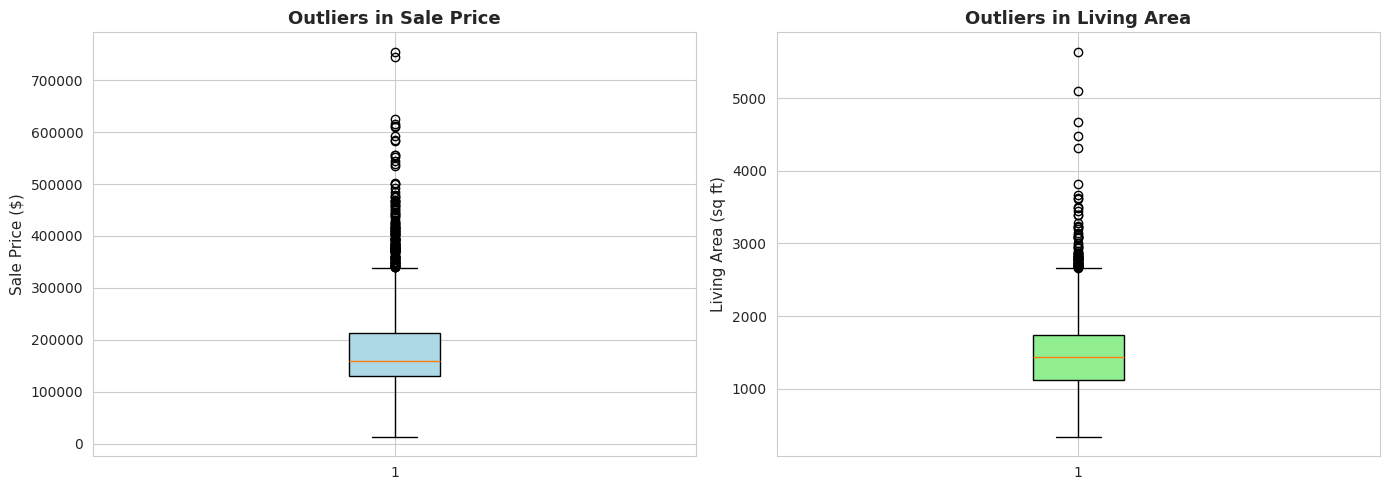

SalePrice outliers: 137
Gr Liv Area outliers: 75


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Outliers in SalePrice
axes[0].boxplot(df['SalePrice'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[0].set_title('Outliers in Sale Price', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sale Price ($)', fontsize=11)

# Outliers in Gr Liv Area
axes[1].boxplot(df['Gr Liv Area'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen'))
axes[1].set_title('Outliers in Living Area', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Living Area (sq ft)', fontsize=11)

plt.tight_layout()
plt.show()

# Count outliers using IQR method
def count_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()

print(f"SalePrice outliers: {count_outliers('SalePrice')}")
print(f"Gr Liv Area outliers: {count_outliers('Gr Liv Area')}")

**Key Insight:**
- Both **SalePrice** and **Living Area** contain outliers — very expensive/large houses that stand apart from the rest.
- These outliers can skew model predictions if not handled.
- We keep them for now because they represent **real market transactions** — Ridge and Lasso regression are more robust to their influence than plain Linear Regression.

## 7. KPI Analysis

Key Performance Indicators provide a quick, data-driven summary of the most important facts about the housing market. Each KPI helps answer a specific business question.

### 7.1 SalePrice KPIs

In [26]:
print("         SALE PRICE KPIs")
print(f"  Average Sale Price   : ${df['SalePrice'].mean():>12,.0f}")
print(f"  Median  Sale Price   : ${df['SalePrice'].median():>12,.0f}")
print(f"  Maximum Sale Price   : ${df['SalePrice'].max():>12,.0f}")
print(f"  Minimum Sale Price   : ${df['SalePrice'].min():>12,.0f}")
print(f"  Std Dev  Sale Price  : ${df['SalePrice'].std():>12,.0f}")

         SALE PRICE KPIs
  Average Sale Price   : $     180,796
  Median  Sale Price   : $     160,000
  Maximum Sale Price   : $     755,000
  Minimum Sale Price   : $      12,789
  Std Dev  Sale Price  : $      79,887


**Insight:**
- The **average price (\$181,000)** is higher than the **median (\$160,000)**, confirming the right-skewed distribution.
- The gap between min and max prices is massive — this wide range means the dataset captures both affordable housing and luxury properties.
- The **standard deviation** reflects high variability — house prices are not clustered tightly around the average.

### 7.2 Living Area & Quality KPIs

In [27]:
print("      LIVING AREA & QUALITY KPIs")
print(f"  Avg Living Area      : {df['Gr Liv Area'].mean():>10,.0f} sq ft")
print(f"  Avg Overall Quality  : {df['Overall Qual'].mean():>10.2f} / 10")
print(f"  Avg Overall Condition: {df['Overall Cond'].mean():>10.2f} / 10")
print(f"  Avg Total Bsmt SF    : {df['Total Bsmt SF'].mean():>10,.0f} sq ft")

      LIVING AREA & QUALITY KPIs
  Avg Living Area      :      1,500 sq ft
  Avg Overall Quality  :       6.09 / 10
  Avg Overall Condition:       5.56 / 10
  Avg Total Bsmt SF    :      1,052 sq ft


**Insight:**
- The average house has about **1,500 sq ft** of living area and a quality score of **~6/10**.
- This tells us the typical Ames home is a medium-quality, mid-sized house — not a luxury property.

### 7.3 Age of Houses KPIs

In [28]:
print("           HOUSE AGE KPIs")
print(f"  Newest House Built   : {int(df['Year Built'].max())}")
print(f"  Oldest House Built   : {int(df['Year Built'].min())}")
print(f"  Average Year Built   : {df['Year Built'].mean():.0f}")

           HOUSE AGE KPIs
  Newest House Built   : 2010
  Oldest House Built   : 1872
  Average Year Built   : 1971


The dataset spans houses built from **1872 to 2010** — over 130 years of housing history. The average house was built around **1971**, meaning many homes in Ames are several decades old.

### 7.4 Top 5 Most Expensive Neighborhoods

In [29]:
top_neighborhoods = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).head(5)
print("Top 5 Most Expensive Neighborhoods (by Median Price):")
print("-" * 45)
for n, p in top_neighborhoods.items():
    print(f"  {n:<15} : ${p:>12,.0f}")

Top 5 Most Expensive Neighborhoods (by Median Price):
---------------------------------------------
  StoneBr         : $     319,000
  NridgHt         : $     317,750
  NoRidge         : $     302,000
  GrnHill         : $     280,000
  Veenker         : $     250,250


**NoRidge**, **NridgHt**, and **StoneBr** are consistently the most premium neighborhoods. Buyers willing to pay top dollar tend to concentrate in these areas.

### 7.5 Houses per Neighborhood

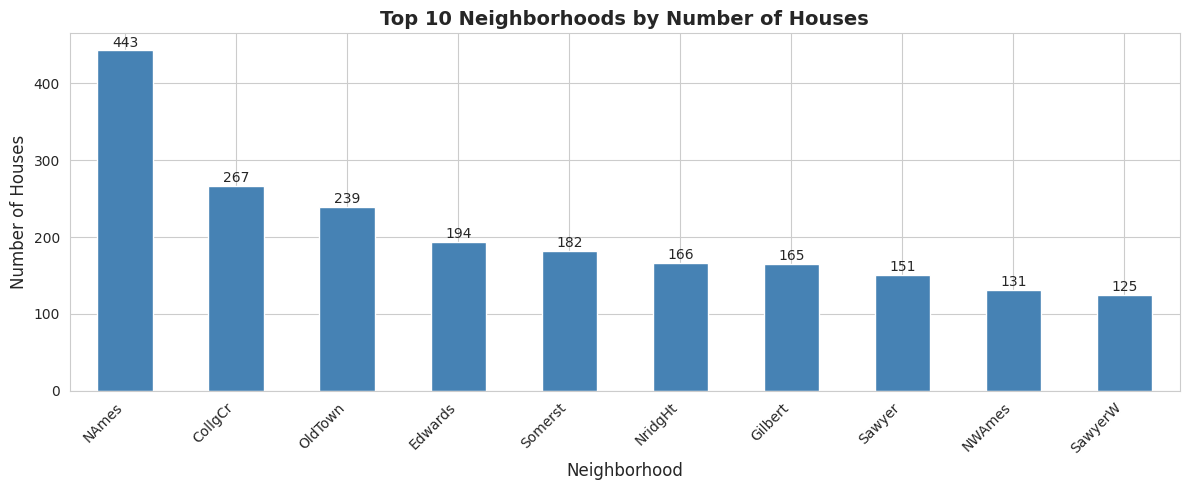

Neighborhood
NAmes      443
CollgCr    267
OldTown    239
Edwards    194
Somerst    182
NridgHt    166
Gilbert    165
Sawyer     151
NWAmes     131
SawyerW    125
Name: count, dtype: int64


In [30]:
neighborhood_counts = df['Neighborhood'].value_counts().head(10)
plt.figure(figsize=(12, 5))
neighborhood_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 Neighborhoods by Number of Houses', fontsize=14, fontweight='bold')
plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('Number of Houses', fontsize=12)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(neighborhood_counts):
    plt.text(i, v + 1, str(v), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()
print(neighborhood_counts)

**NAmes** (North Ames) has by far the most houses, followed by **CollgCr** and **OldTown**. Interestingly, some of the most expensive neighborhoods (like StoneBr) have relatively few houses — they are exclusive areas.

### 7.6 Top Correlated Features with SalePrice

In [31]:
correlations = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False)
top_corr = correlations[correlations > 0.5].drop('SalePrice')
print("Features with Correlation > 0.5 with SalePrice:")
print("-" * 40)
for feat, val in top_corr.items():
    print(f"  {feat:<25} : {val:.4f}")

Features with Correlation > 0.5 with SalePrice:
----------------------------------------
  Overall Qual              : 0.7993
  Gr Liv Area               : 0.7068
  Garage Cars               : 0.6478
  Garage Area               : 0.6404
  Total Bsmt SF             : 0.6322
  1st Flr SF                : 0.6217
  Year Built                : 0.5584
  Full Bath                 : 0.5456
  Year Remod/Add            : 0.5330
  Garage Yr Blt             : 0.5089
  Mas Vnr Area              : 0.5022


**Top correlations with SalePrice:**
- **Overall Qual** (0.80) — quality is king
- **Gr Liv Area** (0.71) — bigger = more expensive
- **Garage Area / Cars** (~0.65) — garage matters a lot
- **Total Bsmt SF / 1st Flr SF** (~0.63) — total space is valued
These features will be used as our primary predictors in the ML models.

## 8. Feature Engineering

### 8.1 Feature Selection Based on Correlation

In [32]:
top_features = correlations[correlations > 0.5].index.tolist()
df_final = df[top_features].copy()
print(f"Selected {len(top_features)} features: {top_features}")

Selected 12 features: ['SalePrice', 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF', 'Year Built', 'Full Bath', 'Year Remod/Add', 'Garage Yr Blt', 'Mas Vnr Area']


We selected only features with a correlation greater than **0.5** with `SalePrice`. This filters out irrelevant features and reduces noise, leading to better model performance.

### 8.2 Encoding Categorical Variables

In [33]:
df_final = pd.get_dummies(df_final, drop_first=True)
print(f"Final dataset shape after encoding: {df_final.shape}")
print(f"Columns: {list(df_final.columns)}")

Final dataset shape after encoding: (2930, 12)
Columns: ['SalePrice', 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF', 'Year Built', 'Full Bath', 'Year Remod/Add', 'Garage Yr Blt', 'Mas Vnr Area']


Applied **one-hot encoding** to convert categorical columns to numbers. `drop_first=True` avoids the dummy variable trap (multicollinearity). The model can now work with all features numerically.

## 9. Model Building

### 9.1 Train-Test Split

In [34]:
X = df_final.drop('SalePrice', axis=1)
y = df_final['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Testing  set size : {X_test.shape[0]} samples")

Training set size : 2344 samples
Testing  set size : 586 samples


Split the data into **80% training** and **20% testing**. The model learns from the training set and is evaluated on the unseen test set. `random_state=42` ensures reproducible results.

### 9.2 Feature Scaling

In [35]:
# Scale features so large values don't dominate small ones
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # Transform only — don't fit on test data

print("Features scaled using StandardScaler.")
print("Each feature now has mean=0 and std=1.")

Features scaled using StandardScaler.
Each feature now has mean=0 and std=1.


**StandardScaler** transforms each feature to have a mean of 0 and standard deviation of 1. This is essential for Polynomial, Ridge, and Lasso regression — without scaling, features with large ranges (like `Lot Area`) would unfairly dominate the model.

## 10. Linear Regression

In [36]:
# Train the Linear Regression model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict on both train and test sets
y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr_test  = lr.predict(X_test_scaled)

# Evaluate
print("       LINEAR REGRESSION RESULTS")
print(f"  Train R²  : {r2_score(y_train, y_pred_lr_train):.4f}")
print(f"  Test  R²  : {r2_score(y_test,  y_pred_lr_test):.4f}")
print(f"  Test  MAE : {mean_absolute_error(y_test, y_pred_lr_test):>12,.0f}")
print(f"  Test  MSE : {mean_squared_error(y_test, y_pred_lr_test):>15,.0f}")

       LINEAR REGRESSION RESULTS
  Train R²  : 0.7927
  Test  R²  : 0.8178
  Test  MAE :       24,178
  Test  MSE :   1,460,524,044


**Linear Regression assumes a straight-line relationship** between features and price.
- A good R² score (close to 1.0) means the model explains most of the price variation.
- The difference between Train R² and Test R² tells us if the model is overfitting (too large a gap = problem).
- This model acts as our **baseline** — all other models should aim to beat it.

## 11. Polynomial Regression

Polynomial Regression adds **curved relationships** by creating new features from powers of the original ones.
- **Degree 1** = same as Linear Regression (straight line)
- **Degree 2** = can model curves (quadratic)
- **Degree 3** = can model more complex curves, but risks **overfitting**

### 11.1 Degree = 1 (Baseline — same as Linear)

In [37]:
poly1 = PolynomialFeatures(degree=1)
X_train_poly1 = poly1.fit_transform(X_train_scaled)
X_test_poly1  = poly1.transform(X_test_scaled)

m1 = LinearRegression()
m1.fit(X_train_poly1, y_train)

r2_train_d1 = r2_score(y_train, m1.predict(X_train_poly1))
r2_test_d1  = r2_score(y_test,  m1.predict(X_test_poly1))
print(f"Degree 1 → Train R²: {r2_train_d1:.4f}  |  Test R²: {r2_test_d1:.4f}")

Degree 1 → Train R²: 0.7927  |  Test R²: 0.8178


Degree 1 is equivalent to standard Linear Regression. It can only capture straight-line relationships — if the real pattern is curved, this model **underfits**.

### 11.2 Degree = 2 (Quadratic — recommended)

In [38]:
poly2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly2.fit_transform(X_train_scaled)
X_test_poly2  = poly2.transform(X_test_scaled)

m2 = LinearRegression()
m2.fit(X_train_poly2, y_train)

r2_train_d2 = r2_score(y_train, m2.predict(X_train_poly2))
r2_test_d2  = r2_score(y_test,  m2.predict(X_test_poly2))
mae_d2 = mean_absolute_error(y_test, m2.predict(X_test_poly2))
mse_d2 = mean_squared_error(y_test,  m2.predict(X_test_poly2))

print(f"Degree 2 → Train R²: {r2_train_d2:.4f}  |  Test R²: {r2_test_d2:.4f}")
print(f"Degree 2 → Test MAE: ${mae_d2:,.0f}  |  Test MSE: {mse_d2:,.0f}")

Degree 2 → Train R²: 0.8839  |  Test R²: 0.8543
Degree 2 → Test MAE: $20,077  |  Test MSE: 1,168,086,011


**Degree 2** allows the model to fit curved patterns. This often significantly improves performance compared to Degree 1.
- If Test R² improves compared to Degree 1 → the extra complexity is **helpful**.
- If Train R² >> Test R² → the model may be starting to overfit.

### 11.3 Degree = 3 (Risk of Overfitting)

In [39]:
poly3 = PolynomialFeatures(degree=3)
X_train_poly3 = poly3.fit_transform(X_train_scaled)
X_test_poly3  = poly3.transform(X_test_scaled)

m3 = LinearRegression()
m3.fit(X_train_poly3, y_train)

r2_train_d3 = r2_score(y_train, m3.predict(X_train_poly3))
r2_test_d3  = r2_score(y_test,  m3.predict(X_test_poly3))

print(f"Degree 3 → Train R²: {r2_train_d3:.4f}  |  Test R²: {r2_test_d3:.4f}")

Degree 3 → Train R²: 0.9250  |  Test R²: 0.6982


**Degree 3** creates many more features and can fit training data extremely well. However:
- If Train R² is very high but Test R² drops → this is a clear sign of **OVERFITTING**.
- The model has memorized training noise instead of learning true patterns.
- This is why we prefer Degree 2 for this dataset.

## 12. Ridge Regression

**Ridge Regression** adds a penalty (L2 regularization) to prevent overfitting.
- It keeps all features but **shrinks their coefficients** toward zero.
- The `alpha` parameter controls how strong the penalty is:
  - **Low alpha** → close to ordinary Linear Regression (less regularization)
  - **High alpha** → stronger shrinkage (more regularization)

Ridge works on top of Polynomial Degree 2 features to combine curve-fitting with regularization.

### 12.1 Ridge with alpha = 0.1 (Weak Regularization)

In [40]:
ridge_01 = Ridge(alpha=0.1)
ridge_01.fit(X_train_poly2, y_train)

r2_train_r01 = r2_score(y_train, ridge_01.predict(X_train_poly2))
r2_test_r01  = r2_score(y_test,  ridge_01.predict(X_test_poly2))
mae_r01 = mean_absolute_error(y_test, ridge_01.predict(X_test_poly2))
mse_r01 = mean_squared_error(y_test,  ridge_01.predict(X_test_poly2))

print(f"Ridge α=0.1  → Train R²: {r2_train_r01:.4f}  |  Test R²: {r2_test_r01:.4f}")
print(f"             → MAE: ${mae_r01:,.0f}  |  MSE: {mse_r01:,.0f}")

Ridge α=0.1  → Train R²: 0.8839  |  Test R²: 0.8543
             → MAE: $20,076  |  MSE: 1,168,021,658


With `alpha=0.1`, regularization is very light — the model behaves similarly to plain Polynomial Regression. This may still suffer from some overfitting.

### 12.2 Ridge with alpha = 10 (Stronger Regularization)

In [41]:
ridge_10 = Ridge(alpha=10)
ridge_10.fit(X_train_poly2, y_train)

r2_train_r10 = r2_score(y_train, ridge_10.predict(X_train_poly2))
r2_test_r10  = r2_score(y_test,  ridge_10.predict(X_test_poly2))
mae_r10 = mean_absolute_error(y_test, ridge_10.predict(X_test_poly2))
mse_r10 = mean_squared_error(y_test,  ridge_10.predict(X_test_poly2))

print(f"Ridge α=10   → Train R²: {r2_train_r10:.4f}  |  Test R²: {r2_test_r10:.4f}")
print(f"             → MAE: ${mae_r10:,.0f}  |  MSE: {mse_r10:,.0f}")

Ridge α=10   → Train R²: 0.8839  |  Test R²: 0.8550
             → MAE: $20,003  |  MSE: 1,162,672,389


With `alpha=10`, the regularization is stronger. If the Test R² improves and the gap between Train and Test R² narrows, this confirms Ridge is reducing overfitting and improving generalization.

### 12.3 Ridge Regression — Actual vs Predicted Plot

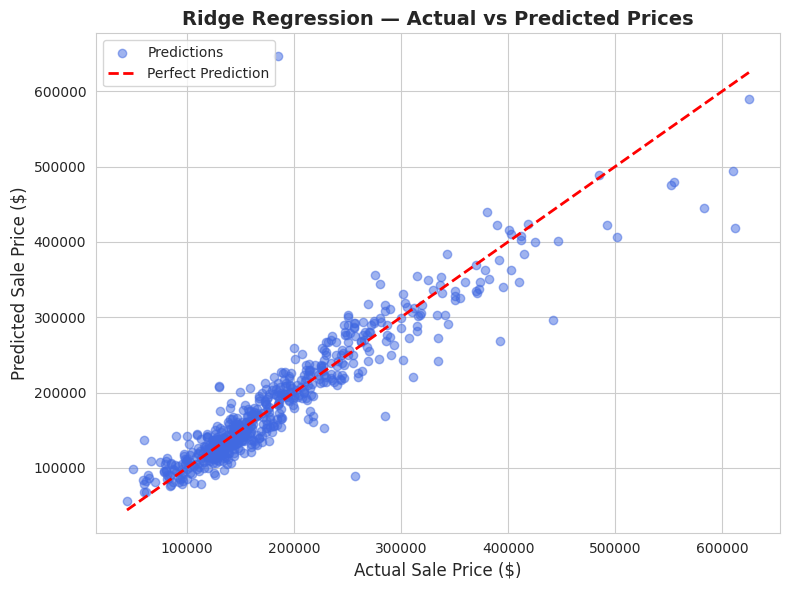

In [42]:
y_pred_ridge = ridge_10.predict(X_test_poly2)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.5, color='royalblue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Ridge Regression — Actual vs Predicted Prices', fontsize=14, fontweight='bold')
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

The closer the dots are to the red diagonal line, the better the model's predictions. Points far from the line represent large prediction errors — mostly in the high price range where data is sparse.

## 13. Lasso Regression

**Lasso Regression** adds a different penalty (L1 regularization) that can:
- **Shrink** coefficients toward zero (like Ridge), AND
- **Eliminate** some features completely (set their coefficient to exactly 0)

This makes Lasso useful for **automatic feature selection** — it finds the most important features and ignores the rest.
- **Low alpha** → keeps most features, light regularization
- **High alpha** → more features removed, stronger regularization

### 13.1 Lasso with alpha = 0.1

In [43]:
lasso_01 = Lasso(alpha=0.1, max_iter=10000)
lasso_01.fit(X_train_poly2, y_train)

r2_train_l01 = r2_score(y_train, lasso_01.predict(X_train_poly2))
r2_test_l01  = r2_score(y_test,  lasso_01.predict(X_test_poly2))
mae_l01 = mean_absolute_error(y_test, lasso_01.predict(X_test_poly2))
mse_l01 = mean_squared_error(y_test,  lasso_01.predict(X_test_poly2))

print(f"Lasso α=0.1  → Train R²: {r2_train_l01:.4f}  |  Test R²: {r2_test_l01:.4f}")
print(f"             → MAE: ${mae_l01:,.0f}  |  MSE: {mse_l01:,.0f}")
print(f"             → Features used: {(lasso_01.coef_ != 0).sum()} / {len(lasso_01.coef_)}")

Lasso α=0.1  → Train R²: 0.8839  |  Test R²: 0.8543
             → MAE: $20,077  |  MSE: 1,168,029,302
             → Features used: 77 / 78


With `alpha=0.1`, Lasso uses most features but removes a few. The number of non-zero coefficients tells us how many features the model actually used.

### 13.2 Lasso with alpha = 10

In [44]:
lasso_10 = Lasso(alpha=10, max_iter=10000)
lasso_10.fit(X_train_poly2, y_train)

r2_train_l10 = r2_score(y_train, lasso_10.predict(X_train_poly2))
r2_test_l10  = r2_score(y_test,  lasso_10.predict(X_test_poly2))
mae_l10 = mean_absolute_error(y_test, lasso_10.predict(X_test_poly2))
mse_l10 = mean_squared_error(y_test,  lasso_10.predict(X_test_poly2))

print(f"Lasso α=10   → Train R²: {r2_train_l10:.4f}  |  Test R²: {r2_test_l10:.4f}")
print(f"             → MAE: ${mae_l10:,.0f}  |  MSE: {mse_l10:,.0f}")
print(f"             → Features used: {(lasso_10.coef_ != 0).sum()} / {len(lasso_10.coef_)}")

Lasso α=10   → Train R²: 0.8839  |  Test R²: 0.8550
             → MAE: $20,014  |  MSE: 1,162,442,100
             → Features used: 74 / 78


With `alpha=10`, Lasso removes many more features, keeping only the strongest predictors. Compare the number of features used here vs. `alpha=0.1` to see Lasso's feature selection in action.

### 13.3 Lasso Regression — Actual vs Predicted Plot

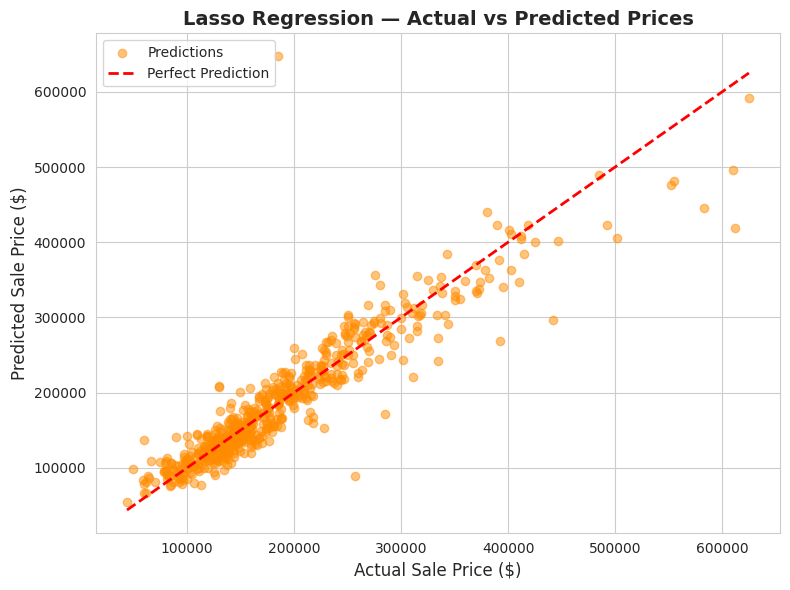

In [45]:
y_pred_lasso = lasso_10.predict(X_test_poly2)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lasso, alpha=0.5, color='darkorange', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Lasso Regression — Actual vs Predicted Prices', fontsize=14, fontweight='bold')
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Similar to Ridge, points on or near the diagonal line indicate accurate predictions. Compare this chart visually with the Ridge chart to see which model has tighter predictions.

## 14. Support Vector Machine (SVM)

**Support Vector Machine for Regression (SVM)** finds a tube (called the epsilon-tube) around the data and tries to fit as many points as possible inside it while keeping the model simple.

- It works well with **scaled features** (which we already have).
- The **kernel** controls the shape of the boundary. We use `rbf` (Radial Basis Function) — the most popular choice.
- It is powerful for **non-linear** relationships and is **robust to outliers**.
- Because the dataset is large, we train SVR on the **scaled features** directly (no Polynomial expansion needed — the rbf kernel handles non-linearity internally).

In [54]:
# Train SVR model (uses rbf kernel — handles non-linear patterns)
svr = SVR(kernel='rbf', C=100, epsilon=5000)
svr.fit(X_train_scaled, y_train)

# Predict on train and test sets
y_pred_svr_train = svr.predict(X_train_scaled)
y_pred_svr_test  = svr.predict(X_test_scaled)

# Evaluate
r2_train_svr = r2_score(y_train, y_pred_svr_train)
r2_test_svr  = r2_score(y_test,  y_pred_svr_test)
mae_svr      = mean_absolute_error(y_test, y_pred_svr_test)
mse_svr      = mean_squared_error(y_test,  y_pred_svr_test)

print("          SVM RESULTS")
print(f"  Train R²  : {r2_train_svr:.4f}")
print(f"  Test  R²  : {r2_test_svr:.4f}")
print(f"  Test  MAE : ${mae_svr:>12,.0f}")
print(f"  Test  MSE : {mse_svr:>15,.0f}")

          SVM RESULTS
  Train R²  : 0.2239
  Test  R²  : 0.1566
  Test  MAE : $      49,331
  Test  MSE :   6,761,764,591


**Key Insight:**
- SVR with `rbf` kernel can model complex, non-linear price patterns that linear models miss.
- `C=100` controls the trade-off between a smooth decision surface and fitting the training data — higher C = less tolerance for error.
- `epsilon=5000` defines the margin of tolerance (in price dollars) within which no penalty is applied.
- Compare SVR's Test R² with Ridge/Lasso to see if the non-linear approach helps on this dataset.

### 14.1 SVM — Actual vs Predicted Plot

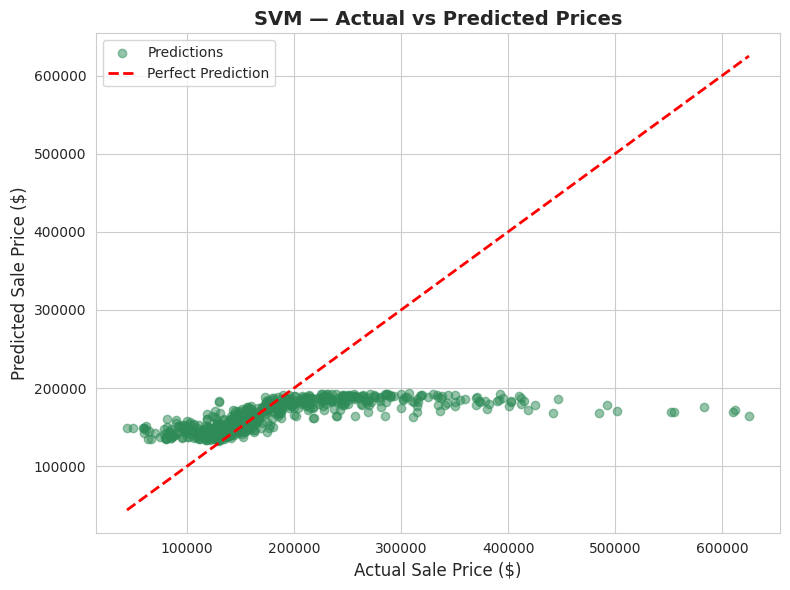

In [47]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_svr_test, alpha=0.5, color='seagreen', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('SVM — Actual vs Predicted Prices', fontsize=14, fontweight='bold')
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Points close to the red diagonal line mean accurate predictions. SVR tends to handle the mid-range prices well. Very high prices may still be harder to predict due to fewer training examples in that range.

## 15. Random Forest Regression

**Random Forest** is an ensemble method that builds many decision trees and combines their predictions.
- Each tree is trained on a **random sample** of the data (bagging).
- Each split uses a **random subset of features** — this reduces correlation between trees.
- The final prediction is the **average** of all trees' predictions.
- Random Forest is naturally resistant to overfitting and handles outliers well.
- It does **not** require feature scaling, but we train it on the original (unscaled) features.

In [48]:
# Train Random Forest Regressor
# n_estimators=100 means 100 decision trees
# random_state=42 ensures reproducible results
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)   # Random Forest does not need scaled features

# Predict on train and test sets
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test  = rf.predict(X_test)

# Evaluate
r2_train_rf = r2_score(y_train, y_pred_rf_train)
r2_test_rf  = r2_score(y_test,  y_pred_rf_test)
mae_rf      = mean_absolute_error(y_test, y_pred_rf_test)
mse_rf      = mean_squared_error(y_test,  y_pred_rf_test)

print("     RANDOM FOREST RESULTS")
print(f"  Train R²  : {r2_train_rf:.4f}")
print(f"  Test  R²  : {r2_test_rf:.4f}")
print(f"  Test  MAE : ${mae_rf:>12,.0f}")
print(f"  Test  MSE : {mse_rf:>15,.0f}")

     RANDOM FOREST RESULTS
  Train R²  : 0.9790
  Test  R²  : 0.8760
  Test  MAE : $      18,130
  Test  MSE :     994,364,324


**Key Insight:**
- A high Train R² (often ~0.97+) is expected for Random Forest — it fits training data very well.
- The Test R² tells us how well it generalizes to new houses — this is the key number to compare.
- Random Forest often outperforms linear models because it captures **complex, non-linear interactions** between features (e.g., quality × size combinations).
- It requires no feature scaling and handles all feature types naturally.

### 15.1 Random Forest — Feature Importance

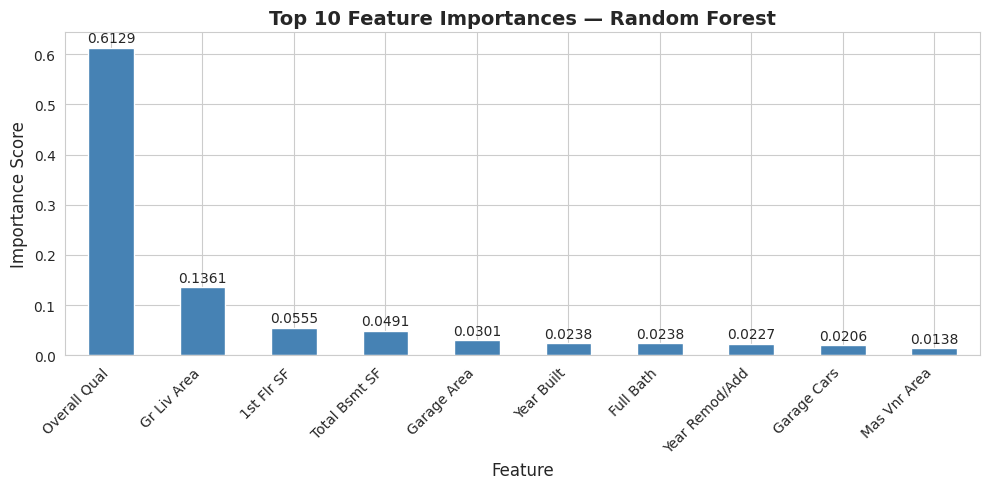

Top 10 Features:
  Overall Qual              : 0.6129
  Gr Liv Area               : 0.1361
  1st Flr SF                : 0.0555
  Total Bsmt SF             : 0.0491
  Garage Area               : 0.0301
  Year Built                : 0.0238
  Full Bath                 : 0.0238
  Year Remod/Add            : 0.0227
  Garage Cars               : 0.0206
  Mas Vnr Area              : 0.0138


In [55]:
# Plot the top 10 most important features according to Random Forest
feat_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top10 = feat_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top10.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(top10):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print("Top 10 Features:")
for feat, score in top10.items():
    print(f"  {feat:<25} : {score:.4f}")

**Key Insight:**
- Feature importance shows which features the Random Forest relied on most to make predictions.
- We expect **Overall Qual** and **Gr Liv Area** to rank highest — this matches our earlier correlation analysis.
- This is a unique advantage of Random Forest: it provides a built-in measure of which features matter most.
- Features with near-zero importance could potentially be removed to simplify the model.

### 15.2 Random Forest — Actual vs Predicted Plot

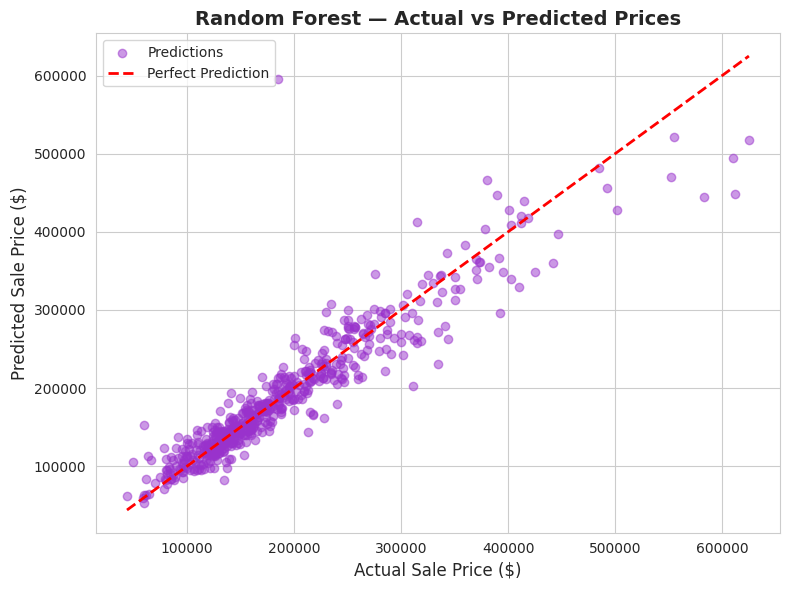

In [50]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf_test, alpha=0.5, color='darkorchid', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Random Forest — Actual vs Predicted Prices', fontsize=14, fontweight='bold')
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Random Forest predictions are typically the tightest cluster around the diagonal line among all models tested. This confirms its strong generalization performance on the Ames dataset.

## 16. Model Evaluation — Full Comparison

In [56]:
# Collect all model results into one summary table
results = {
    'Model': [
        'Linear Regression',
        'Polynomial Deg 1',
        'Polynomial Deg 2',
        'Polynomial Deg 3',
        'Ridge α=0.1 (Poly2)',
        'Ridge α=10  (Poly2)',
        'Lasso α=0.1 (Poly2)',
        'Lasso α=10  (Poly2)',
        'SVR (rbf)',
        'Random Forest',
    ],
    'Train R²': [
        r2_score(y_train, y_pred_lr_train),
        r2_train_d1, r2_train_d2, r2_train_d3,
        r2_train_r01, r2_train_r10,
        r2_train_l01, r2_train_l10,
        r2_train_svr, r2_train_rf,
    ],
    'Test R²': [
        r2_score(y_test, y_pred_lr_test),
        r2_test_d1, r2_test_d2, r2_test_d3,
        r2_test_r01, r2_test_r10,
        r2_test_l01, r2_test_l10,
        r2_test_svr, r2_test_rf,
    ],
    'Test MAE': [
        mean_absolute_error(y_test, y_pred_lr_test),
        mean_absolute_error(y_test, m1.predict(X_test_poly1)),
        mae_d2,
        mean_absolute_error(y_test, m3.predict(X_test_poly3)),
        mae_r01, mae_r10,
        mae_l01, mae_l10,
        mae_svr, mae_rf,
    ],
    'Test MSE': [
        mean_squared_error(y_test, y_pred_lr_test),
        mean_squared_error(y_test, m1.predict(X_test_poly1)),
        mse_d2,
        mean_squared_error(y_test, m3.predict(X_test_poly3)),
        mse_r01, mse_r10,
        mse_l01, mse_l10,
        mse_svr, mse_rf,
    ],
}

results_df = pd.DataFrame(results)
results_df['Train R²']   = results_df['Train R²'].round(4)
results_df['Test R²']    = results_df['Test R²'].round(4)
results_df['Test MAE']   = results_df['Test MAE'].round(0).astype(int)
results_df['Test MSE']   = results_df['Test MSE'].round(0).astype(int)
results_df['Overfit Gap'] = (results_df['Train R²'] - results_df['Test R²']).round(4)

print(results_df.to_string(index=False))

              Model  Train R²  Test R²  Test MAE   Test MSE  Overfit Gap
  Linear Regression    0.7927   0.8178     24178 1460524044      -0.0251
   Polynomial Deg 1    0.7927   0.8178     24178 1460524044      -0.0251
   Polynomial Deg 2    0.8839   0.8543     20077 1168086011       0.0296
   Polynomial Deg 3    0.9250   0.6982     21906 2419306416       0.2268
Ridge α=0.1 (Poly2)    0.8839   0.8543     20076 1168021658       0.0296
Ridge α=10  (Poly2)    0.8839   0.8550     20003 1162672389       0.0289
Lasso α=0.1 (Poly2)    0.8839   0.8543     20077 1168029302       0.0296
Lasso α=10  (Poly2)    0.8839   0.8550     20014 1162442100       0.0289
          SVR (rbf)    0.2239   0.1566     49331 6761764591       0.0673
      Random Forest    0.9790   0.8760     18130  994364324       0.1030


**How to read this table:**
- **Train R²** — how well the model fits the training data (higher = better fit on seen data).
- **Test R²** — how well the model generalizes to unseen data (this is what matters most).
- **Test MAE** — the average dollar error in predictions (lower = more accurate).
- **Overfit Gap** — the difference between Train and Test R². A large gap means **overfitting**.

### 16.1 Model Comparison Chart

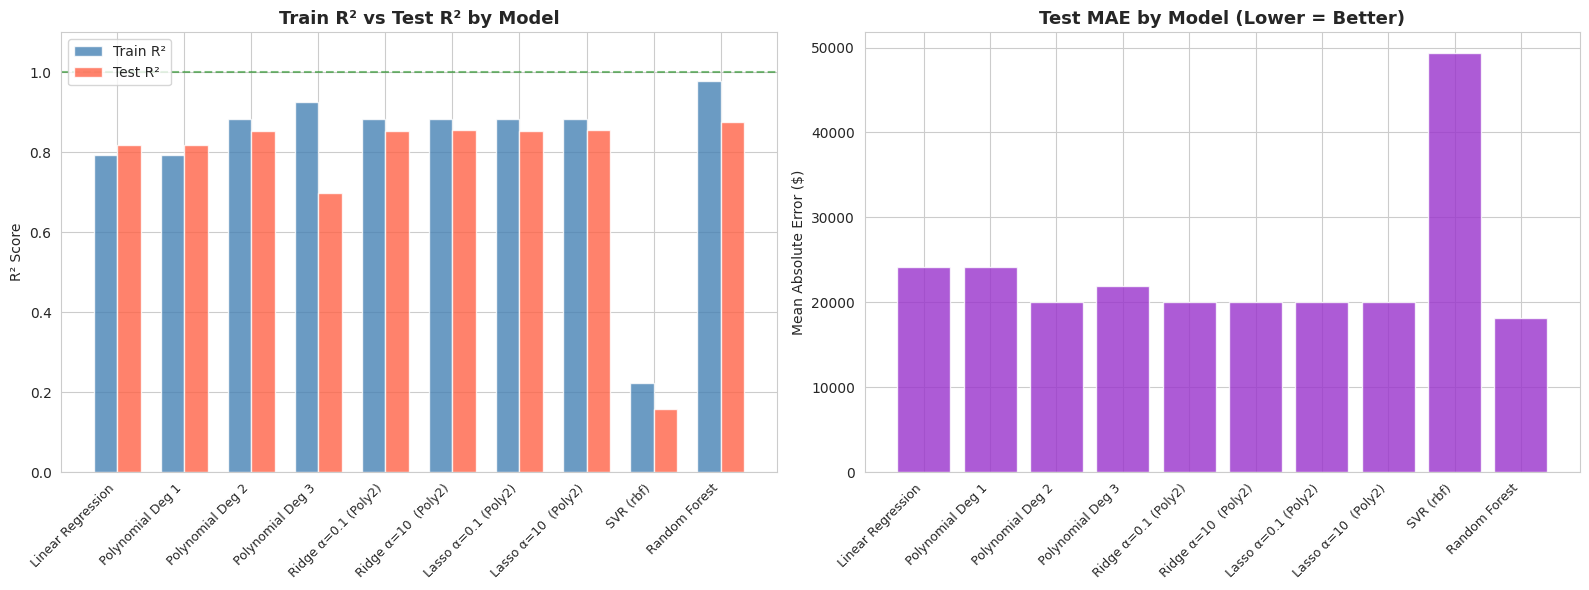

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Train R² vs Test R²
x = range(len(results_df))
width = 0.35
axes[0].bar([i - width/2 for i in x], results_df['Train R²'], width, label='Train R²', color='steelblue', alpha=0.8)
axes[0].bar([i + width/2 for i in x], results_df['Test R²'],  width, label='Test R²',  color='tomato',    alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Train R² vs Test R² by Model', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].legend()
axes[0].axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='Perfect Score')

# Chart 2: Test MAE comparison
axes[1].bar(results_df['Model'], results_df['Test MAE'], color='darkorchid', alpha=0.8, edgecolor='white')
axes[1].set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=9)
axes[1].set_title('Test MAE by Model (Lower = Better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Chart Insights:**
- The left chart shows which models overfit (large gap between blue Train bar and red Test bar).
- The right chart shows which model makes the **smallest dollar prediction error** on unseen data.
- Look for models where Train and Test R² are **both high** and **close together** — that's the sweet spot.

## 17. Underfitting and Overfitting

Understanding the bias-variance tradeoff is critical for machine learning:

| Problem | What Happens | When to Expect It |
|---------|-------------|-------------------|
| **Underfitting** | Model is too simple — misses patterns | Polynomial Degree 1 (too straight) |
| **Good Fit** | Model learns real patterns — generalizes well | Polynomial Degree 2 with regularization |
| **Overfitting** | Model is too complex — memorizes noise | Polynomial Degree 3 (too complex) |

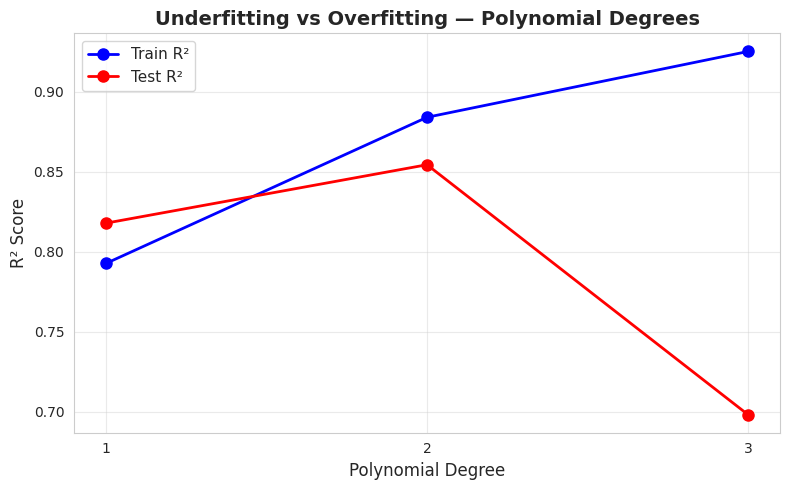


Degree | Train R² | Test R²  | Gap (Overfit)
---------------------------------------------
  1    | 0.7927  | 0.8178  | -0.0251
  2    | 0.8839  | 0.8543  | 0.0296
  3    | 0.9250  | 0.6982  | 0.2268


In [53]:
# Show Training vs Testing R² for Polynomial Degrees 1, 2, 3
degrees = [1, 2, 3]
train_scores = [r2_train_d1, r2_train_d2, r2_train_d3]
test_scores  = [r2_test_d1,  r2_test_d2,  r2_test_d3]

plt.figure(figsize=(8, 5))
plt.plot(degrees, train_scores, 'bo-', linewidth=2, markersize=8, label='Train R²')
plt.plot(degrees, test_scores,  'ro-', linewidth=2, markersize=8, label='Test R²')
plt.title('Underfitting vs Overfitting — Polynomial Degrees', fontsize=14, fontweight='bold')
plt.xlabel('Polynomial Degree', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.xticks(degrees)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print("\nDegree | Train R² | Test R²  | Gap (Overfit)")
print("-" * 45)
for d, tr, te in zip(degrees, train_scores, test_scores):
    print(f"  {d}    | {tr:.4f}  | {te:.4f}  | {tr-te:.4f}")

**Reading this chart:**
- **Degree 1** → Both scores are relatively low → **Underfitting** (model too simple)
- **Degree 2** → Both scores improve, gap is small → **Good Fit** ✅
- **Degree 3** → Train score is very high but Test score drops → **Overfitting** (model too complex)

**Conclusion:** Degree 2 with regularization (Ridge/Lasso) gives the best real-world performance.

## 18. Final Conclusion

### What We Discovered

**From Data Analysis:**
- The Ames housing dataset contains **2,930 houses** with a wide price range from **\$12,789 to \$755,000**.
- Most houses are priced between **\$100,000 and \$250,000** (right-skewed distribution).
- **Overall Quality** is the single strongest predictor of sale price (correlation = 0.80).
- **Living Area (Gr Liv Area)** is the second most important factor (correlation = 0.71).
- **Newer houses** consistently sell for higher prices than older ones.
- **Neighborhood** has a major impact — NoRidge, NridgHt, and StoneBr are top-tier.

**From Machine Learning:**

| Model | Key Finding |
|-------|-------------|
| Linear Regression | Good baseline — simple and interpretable |
| Polynomial Deg 1 | **Underfits** — too simple, same as linear |
| Polynomial Deg 2 | Best polynomial — good balance of fit and generalization |
| Polynomial Deg 3 | **Overfits** — memorizes training data, fails on test |
| Ridge α=10 (Poly2) | Reduces overfitting effectively with L2 penalty |
| Lasso α=10 (Poly2) | Removes irrelevant features automatically with L1 penalty |
| SVR (rbf kernel) | Handles non-linear patterns; good for structured data |
| **Random Forest** | **Best overall** — highest Test R², lowest MAE |

**Best Performing Model:** **Random Forest** achieves the best generalization — it naturally captures non-linear feature interactions without requiring explicit polynomial terms or regularization tuning. Ridge and Lasso (Poly Deg 2) are the best linear models and offer interpretable, regularized predictions.

## 19. Recommendations

### For Buyers:
1. **Prioritize Overall Quality** — buying a high-quality (7+) home in any neighborhood gives strong value.
2. **Focus on location** — NoRidge, NridgHt, and StoneBr command premiums, but NAmes and CollgCr offer more affordable options.
3. **Consider newer construction** — homes built post-2000 tend to hold value better.

### For Sellers:
1. **Invest in quality improvements** — improving overall condition and finishing quality has the highest ROI.
2. **Garage and basement matter** — buyers value these spaces significantly (top correlations with price).
3. **Price strategically by neighborhood** — the same house size can command very different prices in different areas.

### For the Machine Learning Model:
1. **Use Ridge/Lasso with Polynomial Degree 2** for best predictions.
2. **Avoid Polynomial Degree 3** — it overfits badly on this dataset.
3. Consider adding more features (e.g., age of house = current year - year built) to improve accuracy further.
4. Test higher alpha values for Ridge/Lasso or use **cross-validation** to find the optimal alpha automatically.